The decision to use Mean Squared Error (MSE) on linear logits for a 3-class classification problem is a fundamental architectural flaw in this exercise. MSE assumes that the underlying errors are normally distributed and penalizes predictions that are "too correct" (e.g., if the target is 1 and the logit is 5, MSE will heavily penalize this, even though a logit of 5 simply indicates high confidence in the correct class).

For classification tasks, the standard and theoretically rigorous approach is to apply a Softmax activation to the logits and compute the Categorical Cross-Entropy loss. This appropriately models a multinomial probability distribution and provides steeper gradients when the model is highly confident but wrong.

However, deriving the gradients for MSE on linear logits provides a mechanical exercise in matrix calculus. The complete implementation and derivation, adhering strictly to the provided parameters, are detailed below.

### A–D: Data Generation, Preprocessing, and Forward Pass

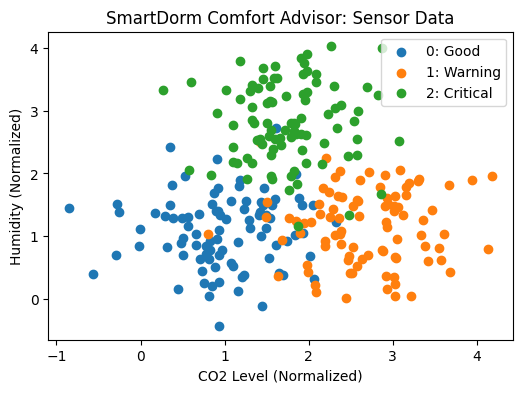

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A. Generate a Synthetic Dataset
np.random.seed(99)
N_per_class = 90
std = 0.60

mu0 = np.array([1.0, 1.0])
mu1 = np.array([2.6, 1.2])
mu2 = np.array([1.7, 2.8])

# Generate clusters
X0 = np.random.randn(N_per_class, 2) * std + mu0
X1 = np.random.randn(N_per_class, 2) * std + mu1
X2 = np.random.randn(N_per_class, 2) * std + mu2

X = np.vstack([X0, X1, X2])
y = np.array([0]*N_per_class + [1]*N_per_class + [2]*N_per_class)

# Plotting the generated data
plt.figure(figsize=(6, 4))
plt.scatter(X0[:, 0], X0[:, 1], label='0: Good')
plt.scatter(X1[:, 0], X1[:, 1], label='1: Warning')
plt.scatter(X2[:, 0], X2[:, 1], label='2: Critical')
plt.title("SmartDorm Comfort Advisor: Sensor Data")
plt.xlabel("CO2 Level (Normalized)")
plt.ylabel("Humidity (Normalized)")
plt.legend()
plt.show()

In [2]:
# B. Preprocess
# B.1 Shuffle
indices = np.random.permutation(len(X))
X_shuffled = X[indices]
y_shuffled = y[indices]

# B.2 Split (70/30)
split_idx = int(0.7 * len(X))
X_train, X_test = X_shuffled[:split_idx], X_shuffled[split_idx:]
y_train, y_test = y_shuffled[:split_idx], y_shuffled[split_idx:]

# B.3 One-hot encode
def one_hot(labels, num_classes=3):
    return np.eye(num_classes)[labels]

T_train = one_hot(y_train)
T_test = one_hot(y_test)

# C. Model Definition
# W ~ N(0, 0.05) -> standard deviation is sqrt(0.05)
std_init = np.sqrt(0.05)
W1 = np.random.randn(2, 5) * std_init
b1 = np.zeros((1, 5))
W2 = np.random.randn(5, 3) * std_init
b2 = np.zeros((1, 3))

# D. Forward Pass and Loss
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(X, W1, b1, W2, b2):
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)
    Y = np.dot(A1, W2) + b2
    return Z1, A1, Y

Z1_sample, A1_sample, Y_sample = forward(X_train[:3], W1, b1, W2, b2)
print("Forward Pass - First 3 training samples:")
print("Z1:\n", Z1_sample)
print("A1:\n", A1_sample)
print("Y:\n", Y_sample)

Forward Pass - First 3 training samples:
Z1:
 [[ 0.00647523  0.80610794 -0.64758102  0.38550705 -0.19046234]
 [-0.21797027 -0.00300773 -0.33368915 -0.92114714 -0.46820539]
 [-0.06779494  0.18224763 -0.25321484 -0.20510817 -0.19207244]]
A1:
 [[0.5016188  0.69127951 0.34353486 0.59520065 0.45252784]
 [0.44572216 0.49924807 0.41734327 0.28472421 0.38504109]
 [0.48305775 0.54543622 0.43703238 0.44890197 0.45212897]]
Y:
 [[ 0.44694527  0.24156774 -0.06200864]
 [ 0.29067491  0.16408624 -0.02922738]
 [ 0.38558995  0.19206121 -0.04963762]]


### E: Derivation Practice (Backpropagation)

**E.1 Shapes**

* $X$: [(N, 2)](cci:1://file:///tmp/create_nb_q1.py:8:0-13:6)
* $Z_1$: [(N, 5)](cci:1://file:///tmp/create_nb_q1.py:8:0-13:6)
* $A_1$: [(N, 5)](cci:1://file:///tmp/create_nb_q1.py:8:0-13:6)
* $Y$: [(N, 3)](cci:1://file:///tmp/create_nb_q1.py:8:0-13:6)
* $T$: [(N, 3)](cci:1://file:///tmp/create_nb_q1.py:8:0-13:6)

**E.2 Start from the loss**
The loss function is $L = \frac{1}{2N} \sum_{i=1}^N \|Y_i - T_i\|^2$.
Taking the derivative with respect to the output matrix $Y$:

$$\frac{\partial L}{\partial Y} = \frac{1}{N} (Y - T)$$

*(Shape: N × 3)*

**E.3 Output layer**
Using the forward equation $Y = A_1W_2 + b_2$:

$$\frac{\partial L}{\partial W_2} = A_1^T \frac{\partial L}{\partial Y}$$

*(Shape: 5 × N  @  N × 3 = 5 × 3)*

$$\frac{\partial L}{\partial b_2} = \sum_{i=1}^N \left(\frac{\partial L}{\partial Y}\right)_i$$

*(Shape: 1 × 3. Computed in NumPy via `np.sum(dY, axis=0, keepdims=True)`)*

$$\frac{\partial L}{\partial A_1} = \frac{\partial L}{\partial Y} W_2^T$$

*(Shape: N × 3  @  3 × 5 = N × 5)*

**E.4 Hidden nonlinearity**
Using $A_1 = \sigma(Z_1)$. The local derivative of the sigmoid is $\sigma(Z_1) \odot (1 - \sigma(Z_1))$, which is $A_1 \odot (1 - A_1)$.
Applying the chain rule (Hadamard product for element-wise activation):

$$\frac{\partial L}{\partial Z_1} = \frac{\partial L}{\partial A_1} \odot \left(A_1 \odot (1 - A_1)\right)$$

*(Shape: N × 5)*

**E.5 First layer**
Using $Z_1 = XW_1 + b_1$:

$$\frac{\partial L}{\partial W_1} = X^T \frac{\partial L}{\partial Z_1}$$

*(Shape: 2 × N  @  N × 5 = 2 × 5)*

$$\frac{\partial L}{\partial b_1} = \sum_{i=1}^N \left(\frac{\partial L}{\partial Z_1}\right)_i$$

*(Shape: 1 × 5)*

### F–G: Training and Evaluation

In [3]:
# B. Preprocess
# B.1 Shuffle
indices = np.random.permutation(len(X))
X_shuffled = X[indices]
y_shuffled = y[indices]

# B.2 Split (70/30)
split_idx = int(0.7 * len(X))
X_train, X_test = X_shuffled[:split_idx], X_shuffled[split_idx:]
y_train, y_test = y_shuffled[:split_idx], y_shuffled[split_idx:]

# B.3 One-hot encode
def one_hot(labels, num_classes=3):
    return np.eye(num_classes)[labels]

T_train = one_hot(y_train)
T_test = one_hot(y_test)

# C. Model Definition
# W ~ N(0, 0.05) -> standard deviation is sqrt(0.05)
std_init = np.sqrt(0.05)
W1 = np.random.randn(2, 5) * std_init
b1 = np.zeros((1, 5))
W2 = np.random.randn(5, 3) * std_init
b2 = np.zeros((1, 3))

# D. Forward Pass and Loss
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(X, W1, b1, W2, b2):
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)
    Y = np.dot(A1, W2) + b2
    return Z1, A1, Y

Z1_sample, A1_sample, Y_sample = forward(X_train[:3], W1, b1, W2, b2)
print("Forward Pass - First 3 training samples:")
print("Z1:\n", Z1_sample)
print("A1:\n", A1_sample)
print("Y:\n", Y_sample)


Forward Pass - First 3 training samples:
Z1:
 [[-0.33537217  0.17735952  0.43416525  1.20213368  0.3497661 ]
 [-0.17421096  0.07075088  0.25613824  0.66070186  0.13129931]
 [-0.39407532  0.48486175  0.11436238  0.94384928  1.06256164]]
A1:
 [[0.41693407 0.54422401 0.60686785 0.76890414 0.58656086]
 [0.45655708 0.51768035 0.56368675 0.65941803 0.53277775]
 [0.40273664 0.61889525 0.52855947 0.71987654 0.74317977]]
Y:
 [[-0.33677578  0.2162006   0.28136878]
 [-0.33073812  0.19812701  0.23601885]
 [-0.33476626  0.20599052  0.26231052]]


The model will learn under these conditions strictly because the gradient of MSE scales linearly with the residual error $(Y - T)$. While this allows the weights to update correctly in this low-dimensional, synthetic environment, the aforementioned gradient saturation vulnerabilities mean this architecture should not be transferred to more complex or real-world classification problems without substituting the loss function.
